# Transportation Frequency and Employment Status

Rachel Rapier (University of Wisconsin, Madison)  
October 15, 2025

The primary purpose of this manuscript is to learn and develop the skills and tools specific to Quarto documents. The simple 2x2 anova was used to examine the relationship between employment status, vehicle access, and total number of days per month an individual uses public transportation or rideshare.

# Introduction:

The type of transportation an individual chooses to use is influenced by a variety of factors, including employment status and access to a vehicle. Workers in America typically drive a personal vehicle to work everyday \[@Yang2015\]. However, public transportation is also commonly used to commute to work, and rideshare services like Uber and Lyft have become increasingly popular in recent years.

Access to a vehicle greatly reduces the need for public transportation and rideshare services. I hypothesize that access to a vehicle will decrease the total number of public transportation and rideshare rides for both full-time employees and individuals with other employment statuses. The null hypothesis is that there is no difference in transportation usage between individuals with and without access to a vehicle.

A full-time employee that works from the office need to commute to the office 20-22 days per month, while part-time employees, contractors, and retirees will not need to commute as frequently. I hypothesize that full-time employed individuals will have higher transportation usage than those with other types of employment status whether or not they have access to a vehicle. The null hypothesis is that there is no difference in transportation usage between full-time employed individuals and those with other types of employment status.

I hypothesize that the effect of having access to a vehicle on total public transportation and rideshare days per month will be stronger for non-full-time employees. ***This is an interaction effect that I should look into more; currently not in the paper***

# Data and Methods

The data was provided by professor Adam Nelson, PhD, at the University of Wisconsin, Madison for the students enrolled in the Data Science in Human Behavior masters program.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import statsmodels.api as sm
from statsmodels.formula.api import ols
from collections import defaultdict

sns.set_context('talk')

dataA = pd.read_csv('data_orig/PRCAProlificExport_FileA.csv')
dataB = pd.read_csv('data_orig/PRCAProlificExport_FileB.csv')
dataC = pd.read_csv('data_orig/PRCAQualtricsExport_FileC.csv')

questions = pd.read_csv('data_dictionary.csv')


# rename the columns to variable_name and question
questions.rename(columns={questions.columns[0]: 'variable_name', questions.columns[1]: 'question'}, inplace=True)

# merge dataframes
data_all = pd.merge(dataA, dataB, how = 'outer')

# Then merge the result with dataC (Q0 in dataC contains Participant id that matches Participant id in dataA/dataB)
data_all = pd.merge(data_all, dataC, left_on='Participant id', right_on='Q0', how='right')

## Data Cleaning

In [2]:
#create an indexing column because participant id a long string of numbers and we want to simplify it. This index will be used as the participant id. Then move it to the first column

data_all['p_id'] = data_all.index
data_all = data_all[['p_id'] + [col for col in data_all.columns if col != 'p_id']]

#drop columns that are not needed   
df = data_all.drop(columns=['EndDate', 'StartDate', 'LocationLatitude', 'LocationLongitude', 'Started at', 'Completed at', 'ResponseId', 'Participant id', 'Submission id', 'Total approvals', 'Country of residence', 'Student status'])

#filter for participants that took more than 30 seconds to complete the survey

df = df[df['Duration (in seconds)']> 30]

df = df.drop(columns=['Duration (in seconds)', 'Time taken'])

In [3]:
# Get unique values for each Q column (excluding Q0)
q_unique_vals = {}
for col in df.columns:
    if col.startswith('Q') and not col.startswith('Q0'):
        unique_vals = tuple(sorted(df[col].dropna().unique()))
        q_unique_vals[col] = unique_vals

# Group columns by their unique values
value_groups = defaultdict(list)
for col, vals in q_unique_vals.items():
    value_groups[vals].append(col)



group2_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'Never': 0
}
group3_mapping = {
  '1-2 rides in a typical day': 1, 
  '3-4 rides in a typical day': 2, 
  '5-6 rides in a typical day': 3, 
  '7 or more rides in a typical day': 4
}

for col in df.columns:
    if col in value_groups[tuple(sorted(group3_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group3_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group2_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group2_mapping)

#rename the new numeric columns something that makes more sense
df = df.rename(columns={
  'Q26_numeric': 'public_trans_per_month', 
  'Q27_numeric': 'public_trans_reg_day', 
  'Q28_numeric': 'rideshare_per_month', 
  'Q29_numeric': 'rideshare_reg_day', 
  'Q21':'Car Access'})


#drop ALL Q columns
df = df.drop(columns=[col for col in df.columns if col.startswith('Q')])

#remove 1 participant that has 'Not Sure' as their car access response
df = df[df['Car Access'] != 'Not Sure']

# create a new column called Full-Time that combines Part-Time and Other into Other for Employment Status
df['Full-Time'] = df['Employment status'].apply(lambda x: 'Other' if x in ['Part-Time', 'Other'] else x)

# create my new outcome variable - total rides
df['total_rides'] = df['public_trans_per_month'] + df['rideshare_per_month']


df = df.drop(columns=['public_trans_reg_day', 'rideshare_reg_day'])

In [4]:
num_rows = df.shape[0]

Participant IDs from the original data set were long complicated strings of letters and numbers. I created a new simplified particpant ID as an index and removed the old long string column.

Following some EDA, I noticed 2 participants completed the survey in less than 30 seconds. That is an unreasonably short amount of time to answer all of the questions, so I removed those participants from the data set, as their responses will not be accurate.

Next I reviewed my independent variables `Car Access` and `Employment status`. To simplify my analysis, I converted `Car Access` into a binary variable (yes/no) and `Employment status` into a binary variable (full-time/other). There was one participant with “Not Sure” as their response for access to a vehicle, so they were removed from the data set. Participants that listed part-time or other employment status were combined into other employment status.

My dependent variable `total_rides` was created by summing the `rideshare days per month` and `public transportation days` per month variables.

Finally, I dropped the variables in the data set that are not used in this analysis. The final cleaned dataset contains 270.participant responses.

Model assumptions were checked in the [supplemental document](supplemental.qmd).

In [5]:
# export the data frame to a csv so I can load it in supplemental.qmd
df.to_csv('cleaned_data.csv', index=False)

## Descriptive Statistics

In [6]:
# Check for any unreasonable values in the dataset

# Create a mapping of variable names to human-readable descriptions
variable_descriptions = {
    'public_trans_per_month': 'Public Transportation Days per Month',
    'rideshare_per_month': 'Rideshare Days per Month',
    'total_rides': 'Total Ride Days per Month', 
    'Age': 'Age'
}

# Get the descriptive statistics and transpose
desc_stats = df.drop(columns = ['p_id']).describe().transpose().apply(lambda x: round(x, 2))

# Add human-readable descriptions as a new column
desc_stats['Variable'] = desc_stats.index.map(variable_descriptions)

# Drop the existing index and set the new column as the index
desc_stats = desc_stats.reset_index(drop=True).set_index('Variable').drop(columns = ['25%', '50%', '75%'])

desc_stats

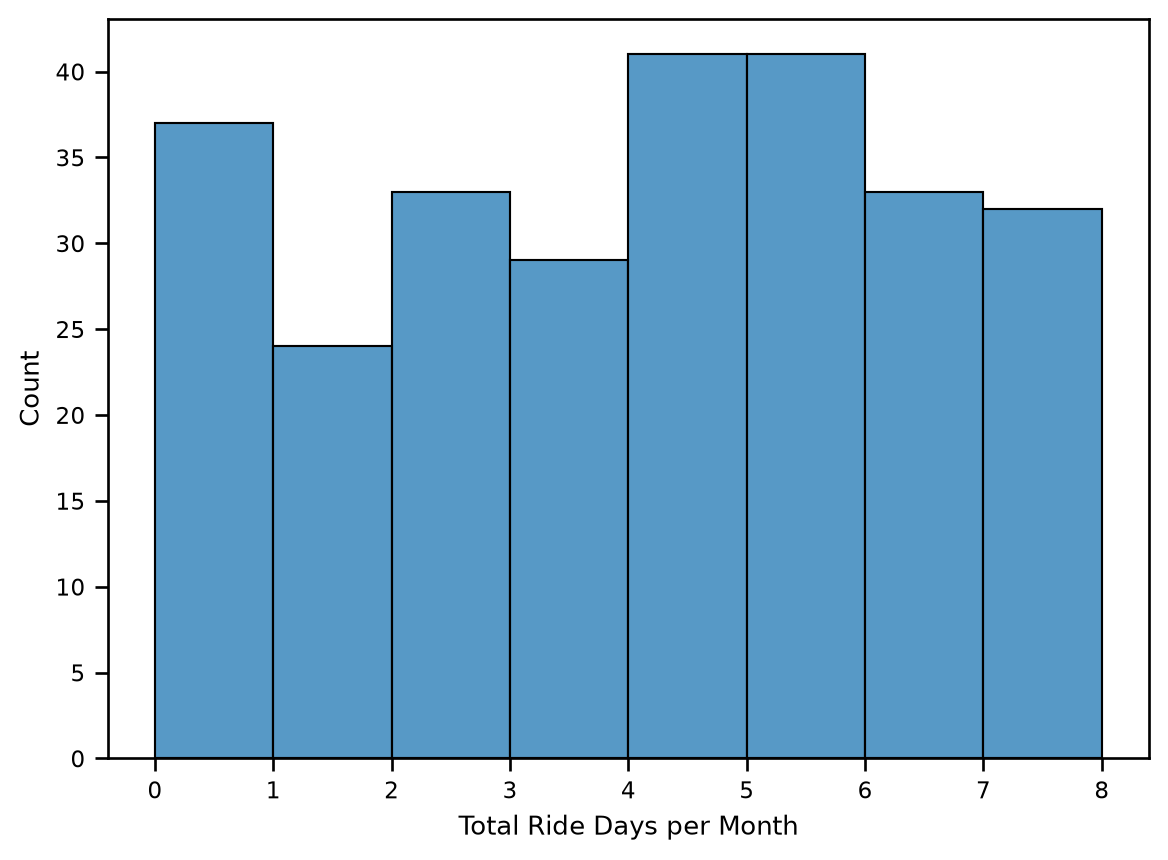

In [7]:
# Drop p_id column
# df_plot = df.drop(columns=['p_id'])

# df_plot.hist(figsize=(8, 10))
sns.set_context('paper')
sns.histplot(data=df,x='total_rides', bins=8)
plt.xlabel('Total Ride Days per Month')

plt.show()

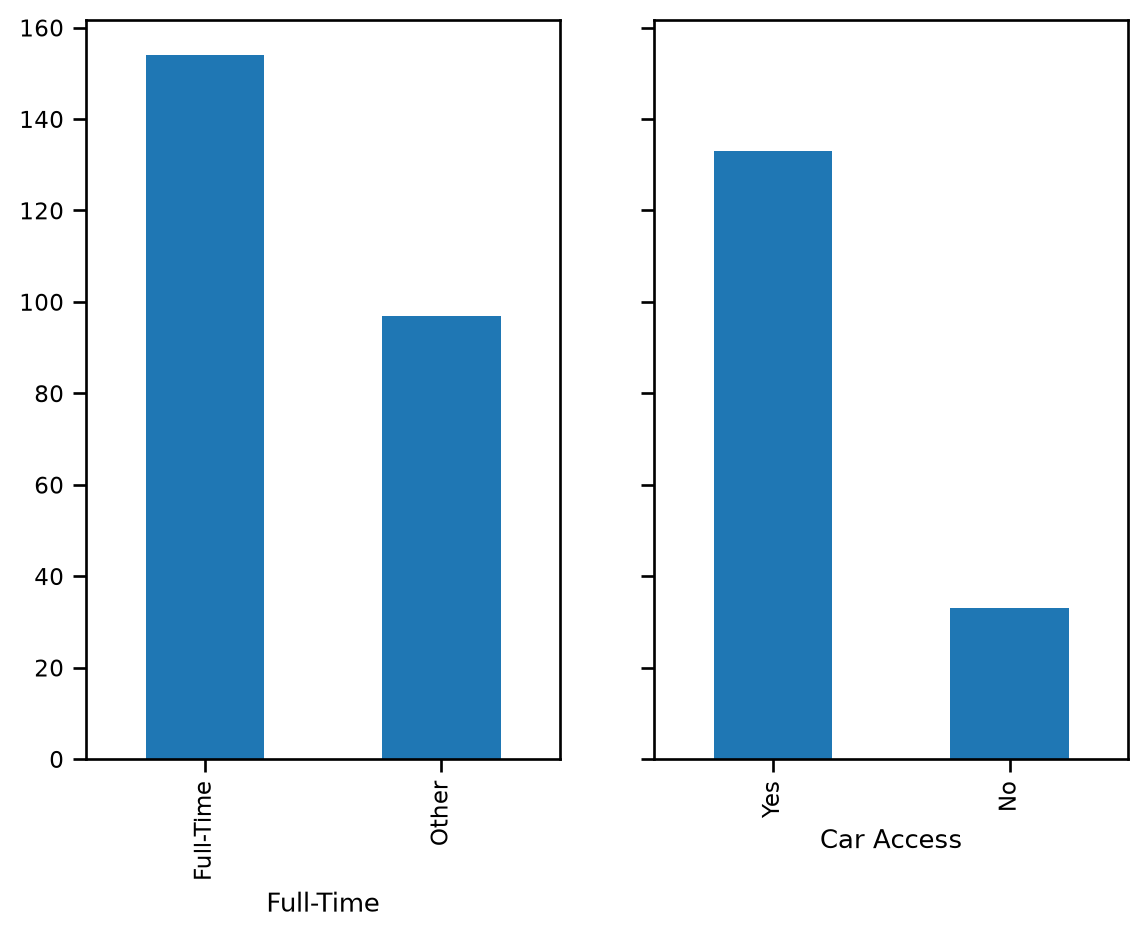

In [8]:
# put value count for employmentstats and for car access in the same figure and make the y axis the same for each plot and don't show the y axis for the 2nd plot
fig, axes = plt.subplots(1, 2, sharey=True)

df['Full-Time'].value_counts().plot(kind='bar', ax=axes[0], rot=90)


df['Car Access'].value_counts().reindex(['Yes', 'No']).plot(
    kind='bar',
    ax=axes[1],
    rot=90
)
plt.show()

***I Cannot Figure Out How to rotate the bar labels in this graph and it is very frustration***

In [9]:
import pandas as pd
from IPython.display import display

# -----------------------------
# Employment status
# -----------------------------

employment_descriptions = {
    'Full-Time': 'Full-Time Employment',
    'Other': 'Other Employment Status'
}

employ_counts = df['Full-Time'].value_counts()

employ_tbl = pd.DataFrame({'count': employ_counts})

employ_tbl['Employment'] = employ_tbl.index.map(
    employment_descriptions
)

employ_tbl = (
    employ_tbl
    .reset_index(drop=True)
    .set_index('Employment')
)

employ_tbl.loc['Total'] = employ_tbl['count'].sum()


# -----------------------------
# Vehicle access
# -----------------------------

VehicleAccess = {
    'Yes': 'Has Access to Vehicle',
    'No': 'No Access to Vehicle'
}

car_counts = df['Car Access'].value_counts()

car_tbl = pd.DataFrame({'count': car_counts})

car_tbl['Vehicle Access'] = car_tbl.index.map(
    VehicleAccess
)

car_tbl = (
    car_tbl
    .reset_index(drop=True)
    .set_index('Vehicle Access')
)

car_tbl.loc['Total'] = car_tbl['count'].sum()


# -----------------------------
# Combine the two tables
# -----------------------------

employ_tbl = employ_tbl.reset_index()
car_tbl = car_tbl.reset_index()

# Make the tables the same number of rows
max_rows = max(len(employ_tbl), len(car_tbl))

employ_tbl = employ_tbl.reindex(range(max_rows))
car_tbl = car_tbl.reindex(range(max_rows))

# Rename columns
employ_tbl.columns = ['Employment Status', 'Count']
car_tbl.columns = ['Vehicle Access', 'Count']

# Combine side-by-side
combined_tbl = pd.concat(
    [employ_tbl, car_tbl],
    axis=1
)

combined_tbl = combined_tbl.reset_index(drop = True)
combined_tbl

@tbl-describe_dataframe give general descriptive statistics of the numeric values of the data, with the mean Total Ride Days per Month equal to 3.63.

@fig-histograms shows the distribution of total ride days per month. This is a uniform distribution and should be noted.

@fig-barplot depicts the counts of participants by employment status and vehicle access and @tbl-cross-tab shows the actual value counts. It should be noted that there are missing values in the data, specifically for the `Car Access` variable, so that is the reason for the different total values.

@tbl-groupby shows the descriptive statistics of my dependent variable `total_rides` by employment status and vehicle access.

In [10]:
grouped = df.groupby(['Full-Time', 'Car Access'])['total_rides'].describe().drop(columns = ['25%', '50%', '75%']).round(2)
grouped

## Methods

I conducted a 2x2 ANOVA to examine the effects of employment status and vehicle access on the total number of rides.

# Results

In [11]:
# Create the ANOVA model (using Q() for column names with special characters)
df['full_time'] = df['Full-Time']
df['car_access'] = df['Car Access']


model = ols('total_rides ~ C(full_time) + C(car_access)', data=df).fit()

In [12]:
# Get the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=3).round(2)

anova_table.index = ['Intercept','Full-Time', 'Car Access', 'Residual']

# Display the ANOVA tables
anova_table

In [13]:
# Get the parameter estimates
params = model.params.round(2)
conf_int = model.conf_int().round(2)
pvalues = model.pvalues.round(3)

# Create a summary table
param_table = pd.DataFrame({
    'Estimate': params,
    '2.5%': conf_int[0],
    '97.5%': conf_int[1],
    'P-value': pvalues
})

#rename the indexes to better names
param_table.index = ['Intercept', 'Full-Time', 'Car Access']

param_table

There is a significant main effect of `Full-Time` on `total_rides` ($F(1, 149) = 12.18$, $p < 0.001$), such that full-time employees have significantly more total ride days per month than other employees.

There is a significant main effect of `Car Access` on `total_rides` ($F(1, 149) = 15.69$, $p < 0.0$), such that individuals with car access have significantly less total ride days per month than other employees.

The parameter estimates refered to in @tbl-parameter-estimates are not interpretable due to converting total ride days per month from a categorical variable to a numerical variable. This is discussed in the limitations section (@sec-limitations).

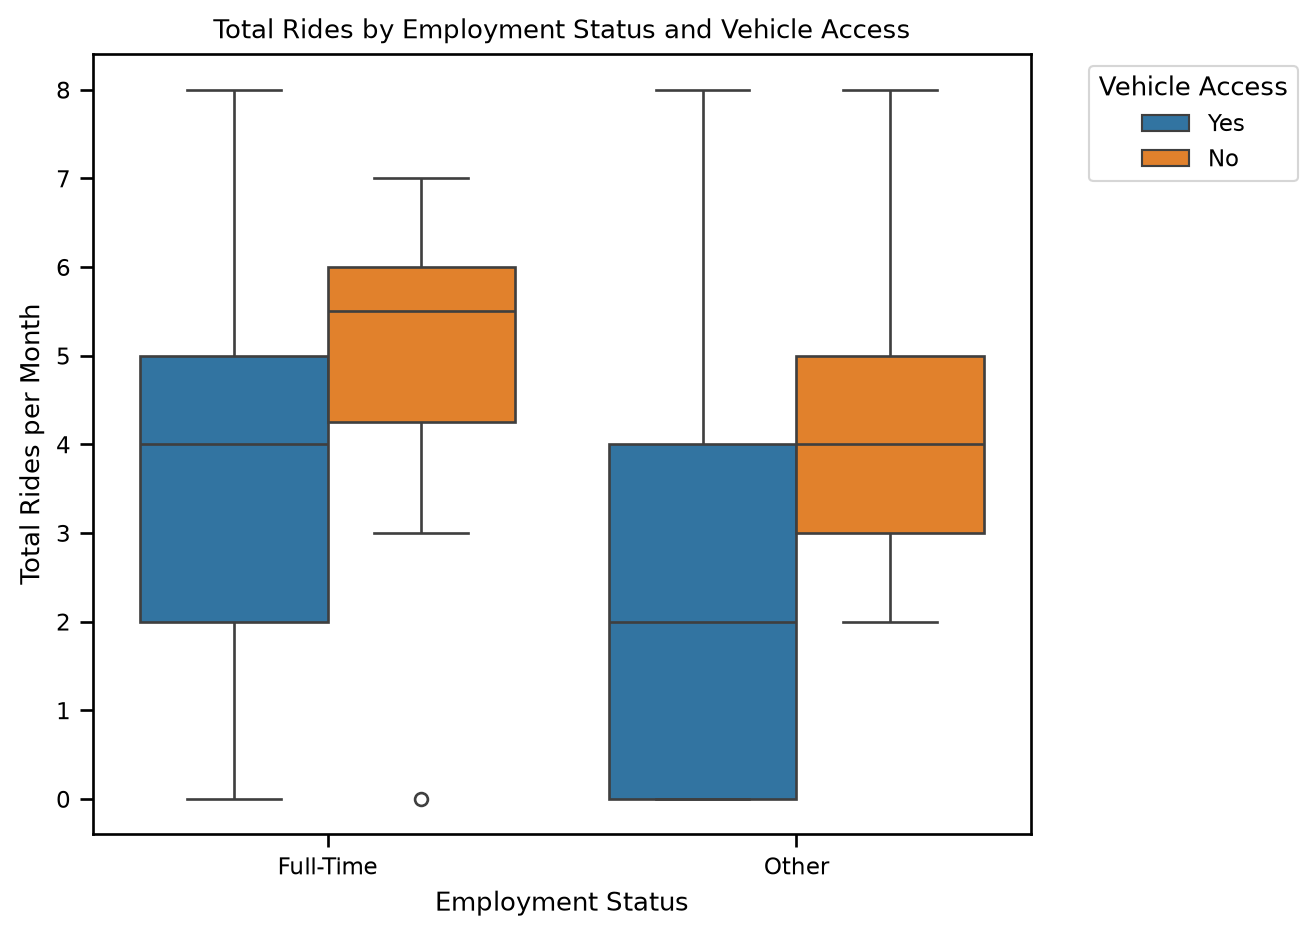

In [14]:
#create a boxplot of total_rides by employment status and vehicle access
sns.set_context('paper')
sns.boxplot(data=df, x='Full-Time', y='total_rides', hue='Car Access')
plt.title('Total Rides by Employment Status and Vehicle Access')
plt.xlabel('Employment Status')
plt.ylabel('Total Rides per Month')
plt.legend(title='Vehicle Access', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

# Conclusion, Future Directions, & Limitations

## Future Directions

Reviewing @fig-boxplot, there appears to be an outlier that is a full-time employee without access to a car with very low ride share and public transportation usage days. It would be interesting to further examine this outlier; however, it seems to be this person may walk to work or work from home.

## Limitations

The distributions of the variables(@fig-barplot, @fig-histograms) are not normal, which may impact the results of the ANOVA test.

The values of `total_rides` are calculated from categorical variables `ride_share_per_month` and `public_trans_per_month` that have unbalanced ranges: 0-1 days a month, 2-4 days a month, 4-8 days a month, 8 or more days a month, Never. Calculating `total_rides` as the sum of these ranges means that the value could represent a different range of actual ride counts. For example: if a participant has a total ride value of 4, they could have 4 ride share days and 0 public transportation days, or 3 ride share days and 1 public transportation day (visa versa), and 2 ride share days and 1 public transportation day. But, when calculating the actual number of days per month, the result could be 8+, 4-9, or 4-8. Therefore, the parameter estimates displayed in @tbl-parameter-estimates are not informative values.

The main conclusion from this analysis is that there is

```` markdown
---
title: "Transportation Frequency and Employment Status"
author: 
  - name: "Rachel Rapier"
    affiliation: "University of Wisconsin, Madison"
date: "2025-10-15"
abstract: |
  The primary purpose of this manuscript is to learn and develop the skills and tools specific to Quarto documents. The simple 2x2 anova was used to examine the relationship between employment status, vehicle access, and total number of days per month an individual uses public transportation or rideshare. 
jupyter: python3
bibliography: references.bib
echo: TRUE
---

# Introduction: 

The type of transportation an individual chooses to use is influenced by a variety of factors, including employment status and access to a vehicle. Workers in America typically drive a personal vehicle to work everyday [@Yang2015]. However, public transportation is also commonly used to commute to work, and rideshare services like Uber and Lyft have become increasingly popular in recent years. 

Access to a vehicle greatly reduces the need for public transportation and rideshare services. I hypothesize that access to a vehicle will decrease the total number of public transportation and rideshare rides for both full-time employees and individuals with other employment statuses. The null hypothesis is that there is no difference in transportation usage between individuals with and without access to a vehicle.

A full-time employee that works from the office need to commute to the office 20-22 days per month, while part-time employees, contractors, and retirees will not need to commute as frequently. I hypothesize that full-time employed individuals will have higher transportation usage than those with other types of employment status whether or not they have access to a vehicle. The null hypothesis is that there is no difference in transportation usage between full-time employed individuals and those with other types of employment status. 

I hypothesize that the effect of having access to a vehicle on total public transportation and rideshare days per month will be stronger for non-full-time employees. ***This is an interaction effect that I should look into more; currently not in the paper***



# Data and Methods

The data was provided by professor Adam Nelson, PhD, at the University of Wisconsin, Madison for the students enrolled in the Data Science in Human Behavior masters program. 

quarto-executable-code-5450563D

```python
#| label: load-packages-data
#| 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
import statsmodels.api as sm
from statsmodels.formula.api import ols
from collections import defaultdict

sns.set_context('talk')

dataA = pd.read_csv('data_orig/PRCAProlificExport_FileA.csv')
dataB = pd.read_csv('data_orig/PRCAProlificExport_FileB.csv')
dataC = pd.read_csv('data_orig/PRCAQualtricsExport_FileC.csv')

questions = pd.read_csv('data_dictionary.csv')


# rename the columns to variable_name and question
questions.rename(columns={questions.columns[0]: 'variable_name', questions.columns[1]: 'question'}, inplace=True)

# merge dataframes
data_all = pd.merge(dataA, dataB, how = 'outer')

# Then merge the result with dataC (Q0 in dataC contains Participant id that matches Participant id in dataA/dataB)
data_all = pd.merge(data_all, dataC, left_on='Participant id', right_on='Q0', how='right')

```


## Data Cleaning

quarto-executable-code-5450563D

```python
#| label: cleaning-data

#create an indexing column because participant id a long string of numbers and we want to simplify it. This index will be used as the participant id. Then move it to the first column

data_all['p_id'] = data_all.index
data_all = data_all[['p_id'] + [col for col in data_all.columns if col != 'p_id']]

#drop columns that are not needed   
df = data_all.drop(columns=['EndDate', 'StartDate', 'LocationLatitude', 'LocationLongitude', 'Started at', 'Completed at', 'ResponseId', 'Participant id', 'Submission id', 'Total approvals', 'Country of residence', 'Student status'])

#filter for participants that took more than 30 seconds to complete the survey

df = df[df['Duration (in seconds)']> 30]

df = df.drop(columns=['Duration (in seconds)', 'Time taken'])

```

quarto-executable-code-5450563D

```python
#| label: map-numeric-values

# Get unique values for each Q column (excluding Q0)
q_unique_vals = {}
for col in df.columns:
    if col.startswith('Q') and not col.startswith('Q0'):
        unique_vals = tuple(sorted(df[col].dropna().unique()))
        q_unique_vals[col] = unique_vals

# Group columns by their unique values
value_groups = defaultdict(list)
for col, vals in q_unique_vals.items():
    value_groups[vals].append(col)



group2_mapping = {
  '0-1 days a month': 1, 
  '2-4 days a month': 2, 
  '4-8 days a month': 3, 
  '8 or more days a month': 4, 
  'Never': 0
}
group3_mapping = {
  '1-2 rides in a typical day': 1, 
  '3-4 rides in a typical day': 2, 
  '5-6 rides in a typical day': 3, 
  '7 or more rides in a typical day': 4
}

for col in df.columns:
    if col in value_groups[tuple(sorted(group3_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group3_mapping)

for col in df.columns:
    if col in value_groups[tuple(sorted(group2_mapping.keys()))]:
        df[col + '_numeric'] = df[col].map(group2_mapping)

#rename the new numeric columns something that makes more sense
df = df.rename(columns={
  'Q26_numeric': 'public_trans_per_month', 
  'Q27_numeric': 'public_trans_reg_day', 
  'Q28_numeric': 'rideshare_per_month', 
  'Q29_numeric': 'rideshare_reg_day', 
  'Q21':'Car Access'})


#drop ALL Q columns
df = df.drop(columns=[col for col in df.columns if col.startswith('Q')])

#remove 1 participant that has 'Not Sure' as their car access response
df = df[df['Car Access'] != 'Not Sure']

# create a new column called Full-Time that combines Part-Time and Other into Other for Employment Status
df['Full-Time'] = df['Employment status'].apply(lambda x: 'Other' if x in ['Part-Time', 'Other'] else x)

# create my new outcome variable - total rides
df['total_rides'] = df['public_trans_per_month'] + df['rideshare_per_month']


df = df.drop(columns=['public_trans_reg_day', 'rideshare_reg_day'])

```

quarto-executable-code-5450563D

```python
#| label: num_rows
num_rows = df.shape[0]

```

Participant IDs from the original data set were long complicated strings of letters and numbers. I created a new simplified particpant ID as an index and removed the old long string column.

Following some EDA, I noticed 2 participants completed the survey in less than 30 seconds. That is an unreasonably short amount of time to answer all of the questions, so I removed those participants from the data set, as their responses will not be accurate. 

Next I reviewed my independent variables `Car Access` and `Employment status`. To simplify my analysis, I converted `Car Access` into a binary variable (yes/no) and `Employment status` into a binary variable (full-time/other). There was one participant with "Not Sure" as their response for access to a vehicle, so they were removed from the data set. Participants that listed part-time or other employment status were combined into other employment status. 

My dependent variable `total_rides` was created by summing the `rideshare days per month` and `public transportation days` per month variables.

Finally, I dropped the variables in the data set that are not used in this analysis. The final cleaned dataset contains `{python} num_rows`.participant responses.

Model assumptions were checked in the [supplemental document](supplemental.qmd). 

quarto-executable-code-5450563D

```python
#| label: export_cleaned_data
# export the data frame to a csv so I can load it in supplemental.qmd
df.to_csv('cleaned_data.csv', index=False)

```

## Descriptive Statistics
quarto-executable-code-5450563D

```python
#| label: tbl-describe_dataframe
#| tbl-cap: "Descriptive statistics for the cleaned dataset"
# Check for any unreasonable values in the dataset

# Create a mapping of variable names to human-readable descriptions
variable_descriptions = {
    'public_trans_per_month': 'Public Transportation Days per Month',
    'rideshare_per_month': 'Rideshare Days per Month',
    'total_rides': 'Total Ride Days per Month', 
    'Age': 'Age'
}

# Get the descriptive statistics and transpose
desc_stats = df.drop(columns = ['p_id']).describe().transpose().apply(lambda x: round(x, 2))

# Add human-readable descriptions as a new column
desc_stats['Variable'] = desc_stats.index.map(variable_descriptions)

# Drop the existing index and set the new column as the index
desc_stats = desc_stats.reset_index(drop=True).set_index('Variable').drop(columns = ['25%', '50%', '75%'])

desc_stats
```

quarto-executable-code-5450563D

```python
#| label: fig-histograms
#| fig-cap: "Histogram of Total Ride Days Per Month"
#| fig-align: center
#| fig-cap-location: top


# Drop p_id column
# df_plot = df.drop(columns=['p_id'])

# df_plot.hist(figsize=(8, 10))
sns.set_context('paper')
sns.histplot(data=df,x='total_rides', bins=8)
plt.xlabel('Total Ride Days per Month')

plt.show()
```

quarto-executable-code-5450563D

```python
#| label: fig-barplot
#| fig-cap: "Bar Plots of Employment Status and Vehicle Access"
#| fig-align: center
#| fig-cap-location: top


# put value count for employmentstats and for car access in the same figure and make the y axis the same for each plot and don't show the y axis for the 2nd plot
fig, axes = plt.subplots(1, 2, sharey=True)

df['Full-Time'].value_counts().plot(kind='bar', ax=axes[0], rot=90)


df['Car Access'].value_counts().reindex(['Yes', 'No']).plot(
    kind='bar',
    ax=axes[1],
    rot=90
)
plt.show()

```

 ***I Cannot Figure Out How to rotate the bar labels in this graph and it is very frustration***

quarto-executable-code-5450563D

```python
#| label: tbl-cross-tab
#| tbl-cap: "Value Counts of Employment Status and Car Access"

import pandas as pd
from IPython.display import display

# -----------------------------
# Employment status
# -----------------------------

employment_descriptions = {
    'Full-Time': 'Full-Time Employment',
    'Other': 'Other Employment Status'
}

employ_counts = df['Full-Time'].value_counts()

employ_tbl = pd.DataFrame({'count': employ_counts})

employ_tbl['Employment'] = employ_tbl.index.map(
    employment_descriptions
)

employ_tbl = (
    employ_tbl
    .reset_index(drop=True)
    .set_index('Employment')
)

employ_tbl.loc['Total'] = employ_tbl['count'].sum()


# -----------------------------
# Vehicle access
# -----------------------------

VehicleAccess = {
    'Yes': 'Has Access to Vehicle',
    'No': 'No Access to Vehicle'
}

car_counts = df['Car Access'].value_counts()

car_tbl = pd.DataFrame({'count': car_counts})

car_tbl['Vehicle Access'] = car_tbl.index.map(
    VehicleAccess
)

car_tbl = (
    car_tbl
    .reset_index(drop=True)
    .set_index('Vehicle Access')
)

car_tbl.loc['Total'] = car_tbl['count'].sum()


# -----------------------------
# Combine the two tables
# -----------------------------

employ_tbl = employ_tbl.reset_index()
car_tbl = car_tbl.reset_index()

# Make the tables the same number of rows
max_rows = max(len(employ_tbl), len(car_tbl))

employ_tbl = employ_tbl.reindex(range(max_rows))
car_tbl = car_tbl.reindex(range(max_rows))

# Rename columns
employ_tbl.columns = ['Employment Status', 'Count']
car_tbl.columns = ['Vehicle Access', 'Count']

# Combine side-by-side
combined_tbl = pd.concat(
    [employ_tbl, car_tbl],
    axis=1
)

combined_tbl = combined_tbl.reset_index(drop = True)
combined_tbl
```

@tbl-describe_dataframe give general descriptive statistics of the numeric values of the data, with the mean Total Ride Days per Month equal to `{python} desc_stats.loc['Total Ride Days per Month', 'mean'].item()`.

@fig-histograms shows the distribution of total ride days per month. This is a uniform distribution and should be noted. 

@fig-barplot depicts the counts of participants by employment status and vehicle access and @tbl-cross-tab shows the actual value counts. It should be noted that there are missing values in the data, specifically for the `Car Access` variable, so that is the reason for the different total values. 

@tbl-groupby shows the descriptive statistics of my dependent variable `total_rides` by employment status and vehicle access.

quarto-executable-code-5450563D

```python
#| label: tbl-groupby
#| tbl-cap: "Descriptive Statistics for Total Rides by Employment Status and Vehicle Access"



grouped = df.groupby(['Full-Time', 'Car Access'])['total_rides'].describe().drop(columns = ['25%', '50%', '75%']).round(2)
grouped
```

## Methods

I conducted a 2x2 ANOVA to examine the effects of employment status and vehicle access on the total number of rides.


# Results

quarto-executable-code-5450563D

```python
#| label: model-create-python

# Create the ANOVA model (using Q() for column names with special characters)
df['full_time'] = df['Full-Time']
df['car_access'] = df['Car Access']


model = ols('total_rides ~ C(full_time) + C(car_access)', data=df).fit()
```

quarto-executable-code-5450563D

```python
#| label: tbl-anova
#| tbl-cap: "2x2 ANOVA results for total rides by employment status and vehicle access"

# Get the ANOVA table
anova_table = sm.stats.anova_lm(model, typ=3).round(2)

anova_table.index = ['Intercept','Full-Time', 'Car Access', 'Residual']

# Display the ANOVA tables
anova_table
```

quarto-executable-code-5450563D

```python
#| label: tbl-parameter-estimates
#| tbl-cap: "Parameter estimates for the ANOVA model"

# Get the parameter estimates
params = model.params.round(2)
conf_int = model.conf_int().round(2)
pvalues = model.pvalues.round(3)

# Create a summary table
param_table = pd.DataFrame({
    'Estimate': params,
    '2.5%': conf_int[0],
    '97.5%': conf_int[1],
    'P-value': pvalues
})

#rename the indexes to better names
param_table.index = ['Intercept', 'Full-Time', 'Car Access']

param_table
```

There is a significant main effect of `Full-Time` on `total_rides` ($F(`{python} int(anova_table.loc['Full-Time', 'df'].item())`, `{python} int(anova_table.loc[ 'Residual', 'df'].item())`) = `{python} anova_table.loc['Full-Time', 'F'].item()`$, $p < `{python} pvalues.iloc[1].item()`$), such that full-time employees have significantly more total ride days per month than other employees.

There is a significant main effect of `Car Access` on `total_rides` ($F(`{python} int(anova_table.loc['Car Access', 'df'].item())`, `{python} int(anova_table.loc[ 'Residual', 'df'].item())`) = `{python} anova_table.loc['Car Access', 'F'].item()`$, $p < `{python} pvalues.iloc[2].item()`$), such that individuals with car access have significantly less total ride days per month than other employees. 

The parameter estimates refered to in @tbl-parameter-estimates are not interpretable due to converting total ride days per month from a categorical variable to a numerical variable. This is discussed in the limitations section (@sec-limitations).



quarto-executable-code-5450563D

```python
#| label: fig-boxplot
#| fig-cap: "Boxplot of total rides by employment status and vehicle access"


#create a boxplot of total_rides by employment status and vehicle access
sns.set_context('paper')
sns.boxplot(data=df, x='Full-Time', y='total_rides', hue='Car Access')
plt.title('Total Rides by Employment Status and Vehicle Access')
plt.xlabel('Employment Status')
plt.ylabel('Total Rides per Month')
plt.legend(title='Vehicle Access', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
```

# Conclusion, Future Directions, & Limitations


## Future Directions
Reviewing @fig-boxplot, there appears to be an outlier that is a full-time employee without access to a car with very low ride share and public transportation usage days. It would be interesting to further examine this outlier; however, it seems to be this person may walk to work or work from home. 

## Limitations {#sec-limitations}

The distributions of the variables(@fig-barplot, @fig-histograms) are not normal, which may impact the results of the ANOVA test.

The values of `total_rides` are calculated from categorical variables `ride_share_per_month` and `public_trans_per_month` that have unbalanced ranges: `{python} ', '.join(group2_mapping.keys())`. Calculating `total_rides` as the sum of these ranges means that the value could represent a different range of actual ride counts. For example: if a participant has a total ride value of 4, they could have 4 ride share days and 0 public transportation days, or 3 ride share days and 1 public transportation day (visa versa), and 2 ride share days and 1 public transportation day. But, when calculating the actual number of days per month, the result could be 8+, 4-9, or  4-8. Therefore, the parameter estimates displayed in @tbl-parameter-estimates are not informative values. 

The main conclusion from this analysis is that there is


::: {#references}

:::
````